In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

This file contains the code to merge the different filters into one single file and converted to boolean for easier access to whether a gene is present.

Venn diagram is set up to compare any 3 filters. Upset plot could not be set up because of dataframe incompatibility

## Loading Datas

In [2]:
pre_filter_path = Path("/project/imoskowitz/yubin/1-sc_practice/Differential_Gene_Analysis/DataFrames/Pre-pseudobulk-filter")
post_filter_path = Path("/project/imoskowitz/yubin/1-sc_practice/Differential_Gene_Analysis/DataFrames/Post-pseudobulk-filter")
pre_filter_path = sorted(pre_filter_path.iterdir())
post_filter_path = sorted(post_filter_path.iterdir())
pre_filters = [] # list of pre filter DEG ranging from genes present in 0-5 cells filter
for file_path in pre_filter_path:
    if file_path.is_file():  
        pre_filters.append(pd.read_csv(file_path))

post_filters = [] # list of post filter DEG ranging from genes present in 0-5 cells filter
for file_path in post_filter_path:
    if file_path.is_file():  
        post_filters.append(pd.read_csv(file_path))



## Displaying the number of genes present in those filters

In [5]:
[len(filter) for filter in pre_filters]

[33696, 26519, 24709, 23640, 22875]

In [6]:
[len(filter) for filter in post_filters]

[33696, 26519, 24456, 22989, 21810, 20516, 19004]

## Venn Diagrams

### Drawing a three set venn diagram:
- the no filter, 2 cell count filter before pseudobulk, and 2 sample count filter after pseudobulk

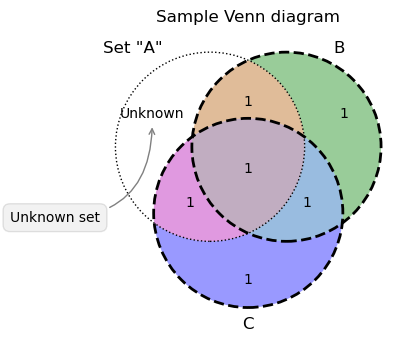

In [7]:

# Example venn diagram
from matplotlib import pyplot as plt
import numpy as np
from matplotlib_venn import venn3, venn3_circles
plt.figure(figsize=(4,4))
v = venn3(subsets=(1, 1, 1, 1, 1, 1, 1), set_labels = ('A', 'B', 'C'))
v.get_patch_by_id('100').set_alpha(1.0)
v.get_patch_by_id('100').set_color('white')
v.get_label_by_id('100').set_text('Unknown')
v.get_label_by_id('A').set_text('Set "A"')
c = venn3_circles(subsets=(1, 1, 1, 1, 1, 1, 1), linestyle='dashed')
c[0].set_lw(1.0)
c[0].set_ls('dotted')
plt.title("Sample Venn diagram")
plt.annotate('Unknown set', xy=v.get_label_by_id('100').get_position() - np.array([0, 0.05]), xytext=(-70,-70),
             ha='center', textcoords='offset points', bbox=dict(boxstyle='round,pad=0.5', fc='gray', alpha=0.1),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.5',color='gray'))
plt.show()

In [8]:
# Sets of gene from all the filter Dataframes
pre_filter_sets = [set(pre_filters[i].iloc[:,0]) for i in range(len(pre_filters))]
post_filter_sets = [set(post_filters[i].iloc[:,0]) for i in range(len(post_filters))]


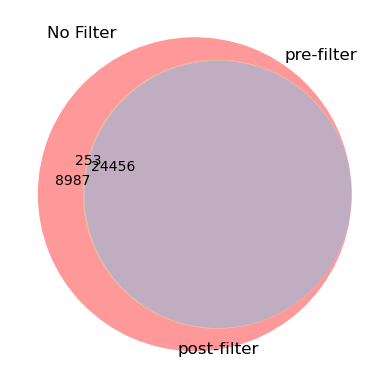

In [9]:
# No filter vs 2 pre vs 2 post
venn3((pre_filter_sets[0], pre_filter_sets[2], post_filter_sets[2]), ('No Filter', 'pre-filter', 'post-filter'))
plt.show()

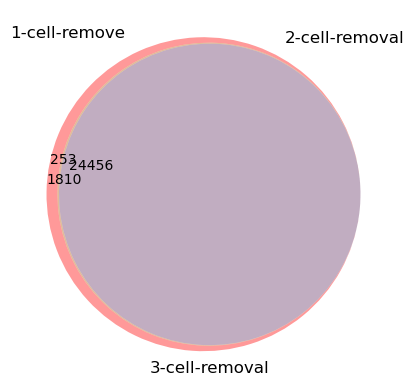

In [10]:

# pre 1 vs 2 vs 3
venn3((pre_filter_sets[1], pre_filter_sets[2], post_filter_sets[2]), ('1-cell-remove', '2-cell-removal', '3-cell-removal'),)
plt.show()

## Generating upset plots


In [11]:
import upsetplot

In [12]:
# Series of gene from all the filter Dataframes
pre_filter_series = [pre_filters[i].iloc[:,0] for i in range(len(pre_filters))]
post_filter_series = [post_filters[i].iloc[:,0] for i in range(len(post_filters))]

# Add Series label 
for i, filter in enumerate(pre_filter_series):
    filter.name = "Pre_filter_" + str(i) + "_cells"
for i, filter in enumerate(post_filter_series):
    filter.name = "Post_filter_" + str(i) + "_cells"

In [20]:
len(pre_filter_series)
len(post_filter_series)
filter_series = pre_filter_series + post_filter_series

In [21]:
filter_series[0]

0                      Xkr4
1                    Gm1992
2                   Gm19938
3                   Gm37381
4                       Rp1
                ...        
33691    ENSMUSG00000095523
33692    ENSMUSG00000095475
33693    ENSMUSG00000094855
33694    ENSMUSG00000095019
33695    ENSMUSG00000095041
Name: Pre_filter_0_cells, Length: 33696, dtype: object

In [24]:
filters = pd.DataFrame(filter_series[0])

In [26]:
filter_series[1].name

'Pre_filter_1_cells'

In [27]:
for i, filter in enumerate(filter_series):
    if i == 0:
        continue
    else:
        filters = filters.merge(pd.DataFrame(filter), left_on="Pre_filter_0_cells", right_on=filter.name, how = "outer")

In [ ]:
filters_na = filters.isna()

In [36]:
filters_na.set_index(filters["Post_filter_0_cells"], inplace = True)
filters_na.index.name = "Gene"

In [38]:
gene_present = ~filters_na

In [39]:
gene_present

,Pre_filter_0_cells,Pre_filter_1_cells,Pre_filter_2_cells,Pre_filter_3_cells,Pre_filter_4_cells,Post_filter_0_cells,Post_filter_1_cells,Post_filter_2_cells,Post_filter_3_cells,Post_filter_4_cells,Post_filter_5_cells,Post_filter_6_cells
Gene,,,,,,,,,,,,
0610005C13Rik,True,True,True,True,True,True,True,True,True,True,True,True
0610006L08Rik,True,True,False,False,False,True,True,False,False,False,False,False
0610009B22Rik,True,True,True,True,True,True,True,True,True,True,True,True
0610009E02Rik,True,True,True,True,True,True,True,True,True,True,True,True
0610009L18Rik,True,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
mt-Nd3,True,True,True,True,True,True,True,True,True,True,True,True
mt-Nd4,True,True,True,True,True,True,True,True,True,True,True,True
mt-Nd4l,True,True,True,True,True,True,True,True,True,True,True,True


In [42]:
gene_present.to_csv("/project/imoskowitz/yubin/1-sc_practice/Differential_Gene_Analysis/DataFrames/genes_present", index=True)

In [40]:
upsetplot.plot(gene_present[gene_present.columns])

AttributeError: 'Index' object has no attribute 'levels'